In [1]:
!pip install networkx numpy

In [2]:
import numpy as np
import networkx as nx
import random
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
def create_sample_graph():
    G = nx.karate_club_graph()

    # Example attributes (random multi attributes)
    attributes = {}
    for node in G.nodes():
        attributes[node] = np.random.randint(0, 3, size=5)

    return G, attributes


Attribute Similarity (SA)

In [4]:
def attribute_similarity(communities, attributes):

    total_sim = 0
    total_pairs = 0

    for community in communities:
        nodes = list(community)

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                sim = cosine_similarity(
                    [attributes[nodes[i]]],
                    [attributes[nodes[j]]]
                )[0][0]

                total_sim += sim
                total_pairs += 1

    if total_pairs == 0:
        return 0

    return total_sim / total_pairs


Modularity (Q)

In [5]:
def modularity(G, communities):
    return nx.algorithms.community.quality.modularity(G, communities)

Chromosome Representation

In [6]:
def create_individual(G):

    # assign random community labels
    labels = {}
    for node in G.nodes():
        labels[node] = random.randint(0, len(G.nodes())//3)

    return labels


def decode(labels):

    communities = {}

    for node, label in labels.items():
        if label not in communities:
            communities[label] = []

        communities[label].append(node)

    return [set(v) for v in communities.values()]

Fitness Evaluation

In [7]:
def evaluate(individual, G, attributes):

    communities = decode(individual)

    Q = modularity(G, communities)
    SA = attribute_similarity(communities, attributes)

    return Q, SA

Crossover

In [8]:
def crossover(parent1, parent2):

    child = parent1.copy()

    for node in child:
        if random.random() < 0.5:
            child[node] = parent2[node]

    return child

Mutation

In [9]:
def mutation(individual, G):

    node = random.choice(list(G.nodes()))
    individual[node] = random.randint(0, len(G.nodes())//3)

    return individual

MOEA-SA Main Loop

In [10]:
def moea_sa(G, attributes, population_size=30, generations=50):

    population = [create_individual(G) for _ in range(population_size)]

    for gen in range(generations):

        new_population = []

        for _ in range(population_size):

            p1, p2 = random.sample(population, 2)

            child = crossover(p1, p2)

            if random.random() < 0.3:
                child = mutation(child, G)

            new_population.append(child)

        population += new_population

        # Evaluate fitness
        scored = [(ind, evaluate(ind, G, attributes)) for ind in population]

        # Pareto sort (simplified)
        scored = sorted(scored, key=lambda x: (x[1][0], x[1][1]), reverse=True)

        population = [x[0] for x in scored[:population_size]]

        print(f"Generation {gen+1} best fitness:", scored[0][1])

    return population[0]

Run Algorithm

In [11]:
G, attributes = create_sample_graph()

best_solution = moea_sa(G, attributes)

communities = decode(best_solution)

print("\nDetected Communities:")
print(communities)

Generation 1 best fitness: (0.005772005772005768, np.float64(0.6722925329273132))
Generation 2 best fitness: (0.02766065103727442, np.float64(0.6694565629537413))
Generation 3 best fitness: (0.03300163040422782, np.float64(0.7295101316776594))
Generation 4 best fitness: (0.048593542100035615, np.float64(0.6559297408981167))
Generation 5 best fitness: (0.048593542100035615, np.float64(0.6559297408981167))
Generation 6 best fitness: (0.055593036112516626, np.float64(0.7391904832757621))
Generation 7 best fitness: (0.06461648020089579, np.float64(0.6677725005364792))
Generation 8 best fitness: (0.06461648020089579, np.float64(0.6677725005364792))
Generation 9 best fitness: (0.08192312737767284, np.float64(0.7449282788420507))
Generation 10 best fitness: (0.08192312737767284, np.float64(0.7449282788420507))
Generation 11 best fitness: (0.09540675774442008, np.float64(0.7282948722924165))
Generation 12 best fitness: (0.09540675774442008, np.float64(0.7282948722924165))
Generation 13 best fi

Graph

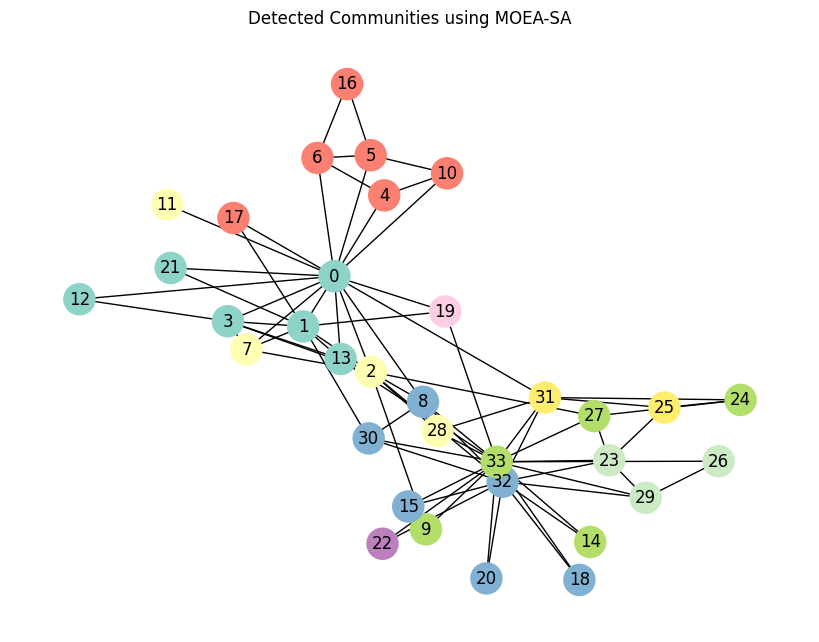

In [12]:
import matplotlib.pyplot as plt

def plot_communities(G, communities):

    pos = nx.spring_layout(G, seed=42)

    colors = []

    for i, community in enumerate(communities):
        for node in community:
            colors.append(i)

    node_color = []
    for node in G.nodes():
        for i, community in enumerate(communities):
            if node in community:
                node_color.append(i)

    plt.figure(figsize=(8,6))

    nx.draw(
        G,
        pos,
        node_color=node_color,
        with_labels=True,
        cmap=plt.cm.Set3,
        node_size=500
    )

    plt.title("Detected Communities using MOEA-SA")
    plt.show()


plot_communities(G, communities)